# Inspect Cluster Lifecycle Report

This notebook loads a `graphcluster` lifecycle report artifact written during a streaming run and gives a quick way to inspect the most useful data without rerunning the trajectory pipeline.

The current report artifact contains:
- trajectory-level summary counts
- per-frame cluster counts and changed-atom counts
- birth, death, split, and merge events
- per-atom switch counts
- simple cluster lifetime records


In [15]:
import sys
print(sys.executable)

/n/home12/lsteinberger/.conda/envs/nequip311/bin/python


In [16]:
from pathlib import Path
from pprint import pprint

from graphcluster.analysis.lifecycle_report import ClusterLifecycleReport

# Change this path if you want to inspect a different run.
REPORT_PATH = Path("/n/home12/lsteinberger/graphcluster/outputs/toy_compare_allegro_robust/cluster_lifecycle_report.jsonl")

if not REPORT_PATH.exists():
    raise FileNotFoundError(f"Could not find report artifact: {REPORT_PATH}")

report = ClusterLifecycleReport.from_path(REPORT_PATH)
REPORT_PATH


PosixPath('/n/home12/lsteinberger/graphcluster/outputs/toy_compare_allegro_robust/cluster_lifecycle_report.jsonl')

In [17]:
print("Source:", report.source_path)
print("Summary:")
pprint(report.get_summary_table())

print("\nEvent counts:")
pprint(report.get_event_counts())


Source: /n/home12/lsteinberger/graphcluster/outputs/toy_compare_allegro_robust/cluster_lifecycle_report.jsonl
Summary:
{'num_atoms': 129,
 'num_frames': 5,
 'num_tracked_clusters': 8,
 'total_births': 8,
 'total_deaths': 2,
 'total_merges': 10,
 'total_splits': 11}

Event counts:
{'total_births': 8, 'total_deaths': 2, 'total_merges': 10, 'total_splits': 11}


In [18]:
births = report.get_births()
deaths = report.get_deaths()
splits = report.get_splits()
merges = report.get_merges()

print("Birth frames:", len(births))
print("Death frames:", len(deaths))
print("Split frames:", len(splits))
print("Merge frames:", len(merges))

print("\nFirst few birth events:")
pprint(births[:3])

print("\nFirst few death events:")
pprint(deaths[:3])

print("\nFirst split frame:")
pprint(splits[:1])

print("\nFirst merge frame:")
pprint(merges[:1])


Birth frames: 4
Death frames: 2
Split frames: 4
Merge frames: 4

First few birth events:
[{'cluster_ids': [0, 1, 2, 3, 4], 'frame_index': 0},
 {'cluster_ids': [5], 'frame_index': 1},
 {'cluster_ids': [6], 'frame_index': 3}]

First few death events:
[{'cluster_ids': [1], 'frame_index': 1}, {'cluster_ids': [6], 'frame_index': 4}]

First split frame:
[{'events': [{'current_cluster_ids': [0, 2, 5], 'previous_cluster_id': 0},
             {'current_cluster_ids': [4, 5], 'previous_cluster_id': 1},
             {'current_cluster_ids': [2, 5], 'previous_cluster_id': 2},
             {'current_cluster_ids': [0, 3], 'previous_cluster_id': 3},
             {'current_cluster_ids': [0, 4], 'previous_cluster_id': 4}],
  'frame_index': 1}]

First merge frame:
[{'events': [{'current_cluster_id': 2, 'previous_cluster_ids': [0, 2]},
             {'current_cluster_id': 4, 'previous_cluster_ids': [1, 4]},
             {'current_cluster_id': 5, 'previous_cluster_ids': [0, 1, 2]}],
  'frame_index': 1}]


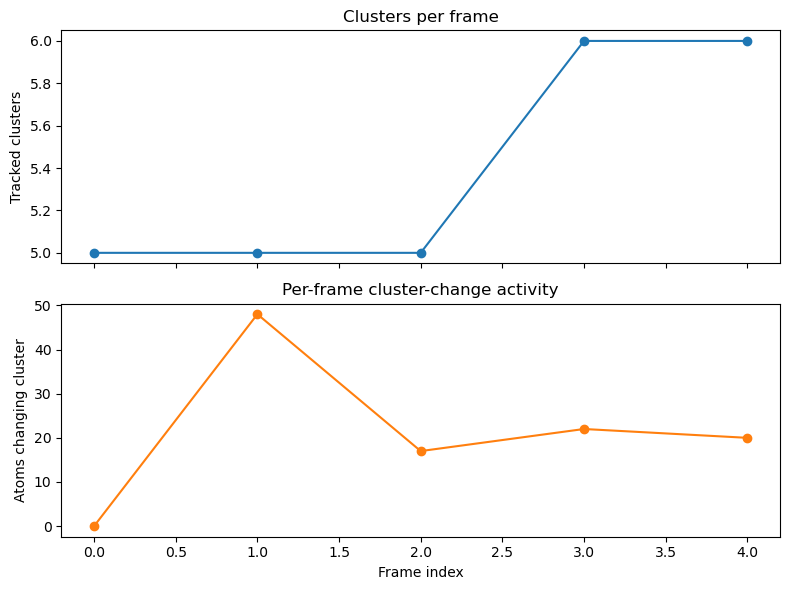

In [19]:
fig, axes = report.plot_cluster_count_timeseries()


Number of atoms: 129
Max switch count: 3
Atoms with at least one switch: 71

Top active atoms:
[{'atom_index': 3, 'switch_count': 3},
 {'atom_index': 8, 'switch_count': 3},
 {'atom_index': 11, 'switch_count': 3},
 {'atom_index': 24, 'switch_count': 3},
 {'atom_index': 35, 'switch_count': 3},
 {'atom_index': 39, 'switch_count': 3},
 {'atom_index': 58, 'switch_count': 3},
 {'atom_index': 81, 'switch_count': 3},
 {'atom_index': 105, 'switch_count': 3},
 {'atom_index': 0, 'switch_count': 2}]


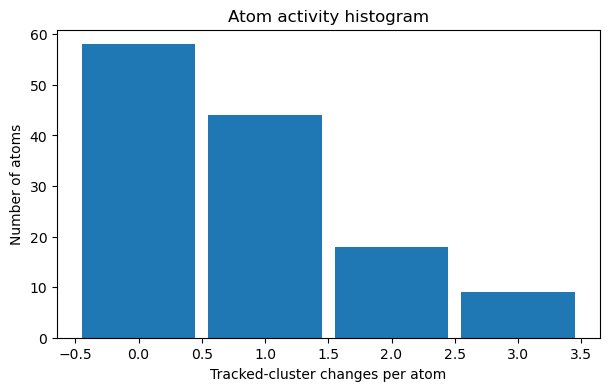

In [20]:
atom_switch_counts = report.get_atom_switch_counts()

print("Number of atoms:", len(atom_switch_counts))
print("Max switch count:", max(atom_switch_counts) if atom_switch_counts else 0)
print("Atoms with at least one switch:", report.get_num_active_atoms(min_switches=1))

print("\nTop active atoms:")
pprint(report.get_top_atoms_by_switches(10))

fig, ax = report.plot_atom_switch_histogram()


Top cluster lifetimes:
[{'cluster_id': 0,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 2,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 3,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 4,
  'first_seen_frame': 0,
  'frames_observed': 5,
  'last_seen_frame': 4},
 {'cluster_id': 5,
  'first_seen_frame': 1,
  'frames_observed': 4,
  'last_seen_frame': 4},
 {'cluster_id': 1,
  'first_seen_frame': 0,
  'frames_observed': 1,
  'last_seen_frame': 0},
 {'cluster_id': 6,
  'first_seen_frame': 3,
  'frames_observed': 1,
  'last_seen_frame': 3},
 {'cluster_id': 7,
  'first_seen_frame': 4,
  'frames_observed': 1,
  'last_seen_frame': 4}]


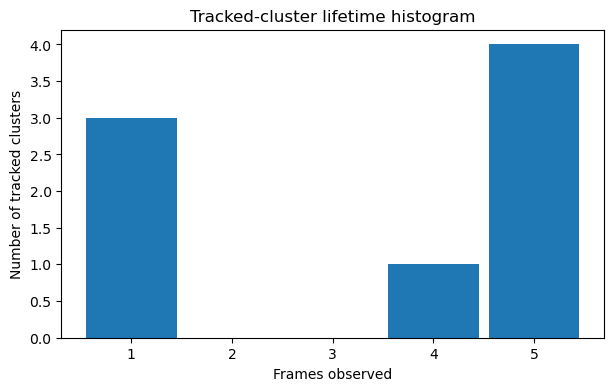

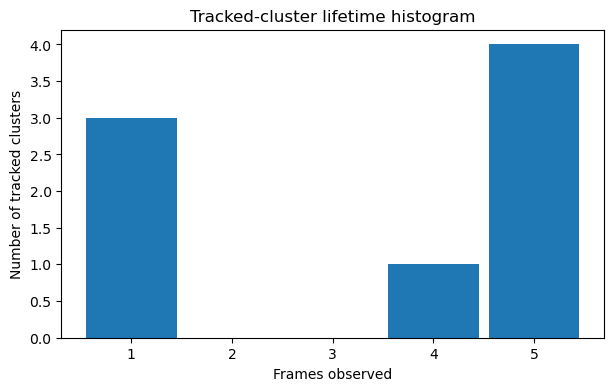

In [21]:
print("Top cluster lifetimes:")
pprint(report.get_longest_lived_clusters(10))

fig, ax = report.plot_cluster_lifetime_histogram()
fig


## Next ideas

Natural extensions for this notebook later:
- filter events for a specific frame or tracked cluster
- compare report events against the visualization artifact for the same frame
- plot match-confidence distributions once those are exposed on the report facade
- export selected tables to CSV for external analysis
